# Notebook 06 — Testes das Hipóteses (H1 metodológica e H2 territorial)

**Projeto:** Acessibilidade Geográfica às UBS de Teresina — roteiro computacional AE2SFCA  
**Programa:** MAPEPROF / IFPI | **Autor:** Felipe Ramos Dantas  
**Orientador:** Prof. Dr. Antonio Joaquim da Silva | **Coorientador:** Prof. Dr. Reurysson Chagas de Sousa Morais  
**Repositório:** https://github.com/felipedantas-pi/ae2sfca-ubs 

---
## Objetivo
Testar as hipóteses: **H1** (o diagnóstico areal difere do E2SFCA tradicional) e **H2** (a
acessibilidade associa-se à renda, com exclusão na periferia). Métodos: correlação de
Spearman, reclassificação de "desertos" e autocorrelação espacial (Moran/LISA).

## Entrada
| Arquivo | Origem |
|---|---|
| `processados/teresina_setores_acessibilidade.parquet` | NB 05 |
| `intermediarios/01_malha/teresina_setoresCensitarios_DadosCompletos.parquet` (renda V06004) | NB 01.1 |
---

In [1]:
# ── 1. IMPORTAÇÕES ──────────────────────────────────────────────────────────
import warnings
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import spearmanr
from libpysal.weights import KNN
from esda.moran import Moran, Moran_BV, Moran_Local_BV

from mapeprof.config import PROCESSADOS, INT_MALHA, FIGURAS, CRS_METRICO, criar_diretorios
from mapeprof.viz import aplicar_estilo, barra_escala, seta_norte, moldura_mapa
aplicar_estilo(); warnings.filterwarnings("ignore"); criar_diretorios()
FIGURAS_NB = FIGURAS / "nb061"; FIGURAS_NB.mkdir(parents=True, exist_ok=True)
print("✅ Setup concluído.")

✅ Setup concluído.


In [2]:
# ── 2. CARGA: ACESSIBILIDADE (NB 05) + RENDA (NB 01.1) ──────────────────────
ac = gpd.read_parquet(PROCESSADOS / "teresina_setores_acessibilidade.parquet").to_crs(CRS_METRICO)
renda = (gpd.read_parquet(INT_MALHA / "teresina_setoresCensitarios_DadosCompletos.parquet")
         [["CD_SETOR", "V06004_renda"]].rename(columns={"V06004_renda": "renda_media"}))
renda["renda_media"] = pd.to_numeric(renda["renda_media"], errors="coerce")
ac = ac.merge(renda, on="CD_SETOR", how="left")
print(f"🔄 {len(ac)} setores | com renda: {ac['renda_media'].notna().sum()}")

🔄 1403 setores | com renda: 1385


## 3. Teste de H1 — abordagem areal vs. tradicional (centroide)

Compara-se o índice AE2SFCA areal (`acess_carro`) ao E2SFCA por centroide
(`acess_carro_e2sfca`), sob idêntica parametrização. A divergência é medida pela correlação
de postos e pela contagem de setores que mudam de classificação "deserto de saúde".

In [3]:
# ── 3. H1 ───────────────────────────────────────────────────────────────────
val = ac[(ac["acess_carro"] > 0) & (ac["acess_carro_e2sfca"] > 0)]
rho_h1, _ = spearmanr(val["acess_carro"], val["acess_carro_e2sfca"])

lim_areal = ac.loc[ac["acess_carro"] > 0, "acess_carro"].quantile(0.25)
lim_cent  = ac.loc[ac["acess_carro_e2sfca"] > 0, "acess_carro_e2sfca"].quantile(0.25)
ac["deserto_areal"] = ac["acess_carro"] <= lim_areal
ac["deserto_cent"]  = ac["acess_carro_e2sfca"] <= lim_cent
ac["reclassificado"] = ac["deserto_areal"] != ac["deserto_cent"]

print(f"H1 | Spearman areal×centroide = {rho_h1:.3f}")
print(f"   desertos: areal={int(ac['deserto_areal'].sum())} | centroide={int(ac['deserto_cent'].sum())}")
print(f"   setores reclassificados pela abordagem areal: {int(ac['reclassificado'].sum())} "
      f"({ac['reclassificado'].mean()*100:.1f}%)")

H1 | Spearman areal×centroide = 0.990
   desertos: areal=362 | centroide=363
   setores reclassificados pela abordagem areal: 25 (1.8%)


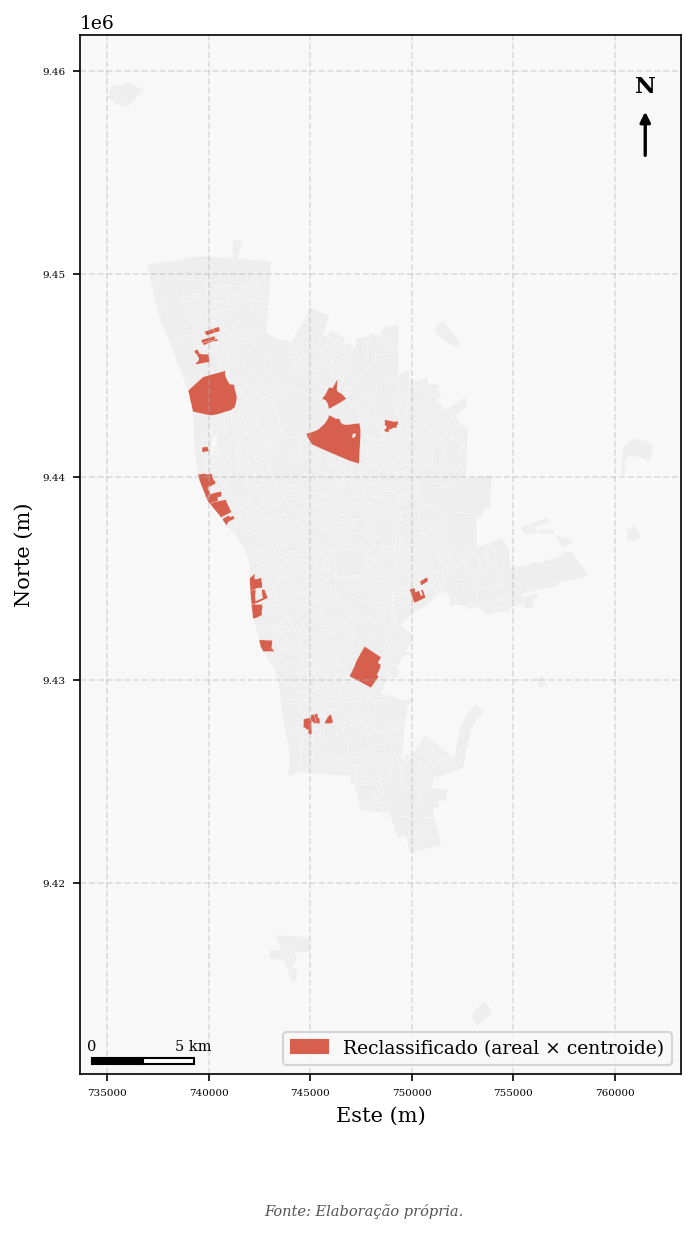

In [4]:
# ── Fig. 01 — Setores reclassificados pela abordagem areal ──────────────────
fig, ax = plt.subplots(figsize=(9, 9))
ac.plot(ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.1)
ac[ac["reclassificado"]].plot(ax=ax, color="#D6604D", edgecolor="white", linewidth=0.1)
ax.legend(handles=[Patch(color="#D6604D", label="Reclassificado (areal × centroide)")],
          loc="lower right")
moldura_mapa(ax, "", "Elaboração própria.")
barra_escala(ax); seta_norte(ax)
plt.savefig(FIGURAS_NB / "nb061_fig01_h1_divergencias.png", bbox_inches="tight")
plt.show()

## 4. Teste de H2 — acessibilidade e renda

Avalia-se a associação entre o índice de acessibilidade e a renda média do responsável,
pela correlação de Spearman (associação global) e pela autocorrelação espacial bivariada
de Moran e seus indicadores locais (LISA), identificando agrupamentos significativos de
baixa acessibilidade e baixa renda (*low-low*).

In [5]:
# ── 4. H2 ───────────────────────────────────────────────────────────────────
sub = ac[ac["renda_media"].notna() & (ac["acess_carro"] > 0)].reset_index(drop=True)
rho_h2, p_h2 = spearmanr(sub["acess_carro"], sub["renda_media"])

w = KNN.from_dataframe(sub, k=8); w.transform = "r"   # KNN evita "ilhas" do Queen
moran_acesso = Moran(sub["acess_carro"].values, w)
moran_bv = Moran_BV(sub["acess_carro"].values, sub["renda_media"].values, w)
lisa = Moran_Local_BV(sub["acess_carro"].values, sub["renda_media"].values, w, seed=42)

# Quadrantes esda: 1=Alto-Alto, 2=Baixo-Alto, 3=Baixo-Baixo, 4=Alto-Baixo
SIG = lisa.p_sim < 0.05
ROTULO = {1: "Alto acesso–Alta renda", 2: "Baixo acesso–Alta renda",
          3: "Baixo acesso–Baixa renda", 4: "Alto acesso–Baixa renda"}
sub["cluster"] = np.where(SIG, pd.Series(lisa.q).map(ROTULO), "Não significativo")

print(f"H2 | Spearman acesso×renda = {rho_h2:+.3f} (p={p_h2:.1e})  → associação POSITIVA")
print(f"   Moran I global do acesso = {moran_acesso.I:.3f} (p={moran_acesso.p_sim:.3f})")
print(f"   Moran bivariado acesso×renda = {moran_bv.I:+.3f} (p={moran_bv.p_sim:.3f})")
print("   clusters LISA significativos:")
print(sub.loc[SIG, "cluster"].value_counts().to_string())

H2 | Spearman acesso×renda = +0.508 (p=7.1e-91)  → associação POSITIVA
   Moran I global do acesso = 0.934 (p=0.001)
   Moran bivariado acesso×renda = +0.365 (p=0.001)
   clusters LISA significativos:
cluster
Baixo acesso–Baixa renda    309
Alto acesso–Alta renda      152
Alto acesso–Baixa renda      92
Baixo acesso–Alta renda       8


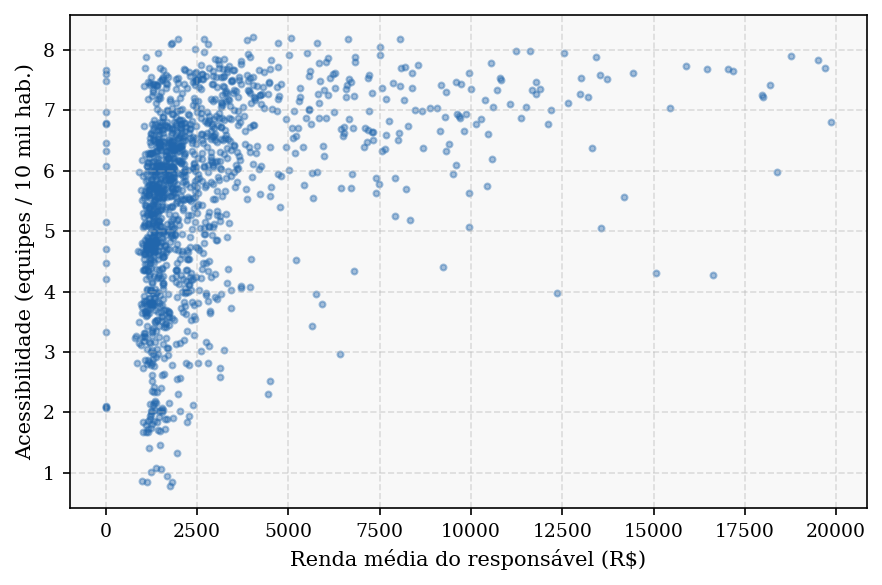

In [6]:
# ── Fig. 02 — Dispersão acesso × renda ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(sub["renda_media"], sub["acess_carro"] * 1e4, s=8, alpha=0.4, color="#2166AC")
ax.set_xlabel("Renda média do responsável (R$)")
ax.set_ylabel("Acessibilidade (equipes / 10 mil hab.)")
plt.tight_layout()
plt.savefig(FIGURAS_NB / "nb061_fig02_h2_dispersao.png", bbox_inches="tight")
plt.show()

In [7]:
# guarda quadrante e significância diretamente (sem depender de strings)
sub["q"]   = lisa.q              # 1=Alto-Alto, 2=Baixo-Alto, 3=Baixo-Baixo, 4=Alto-Baixo
sub["sig"] = lisa.p_sim < 0.05
print("clusters LISA significativos:")
print(pd.Series(lisa.q[sub['sig']]).map(
    {1:"HH",2:"LH",3:"LL",4:"HL"}).value_counts().to_string())

clusters LISA significativos:
LL    309
HH    152
HL     92
LH      8


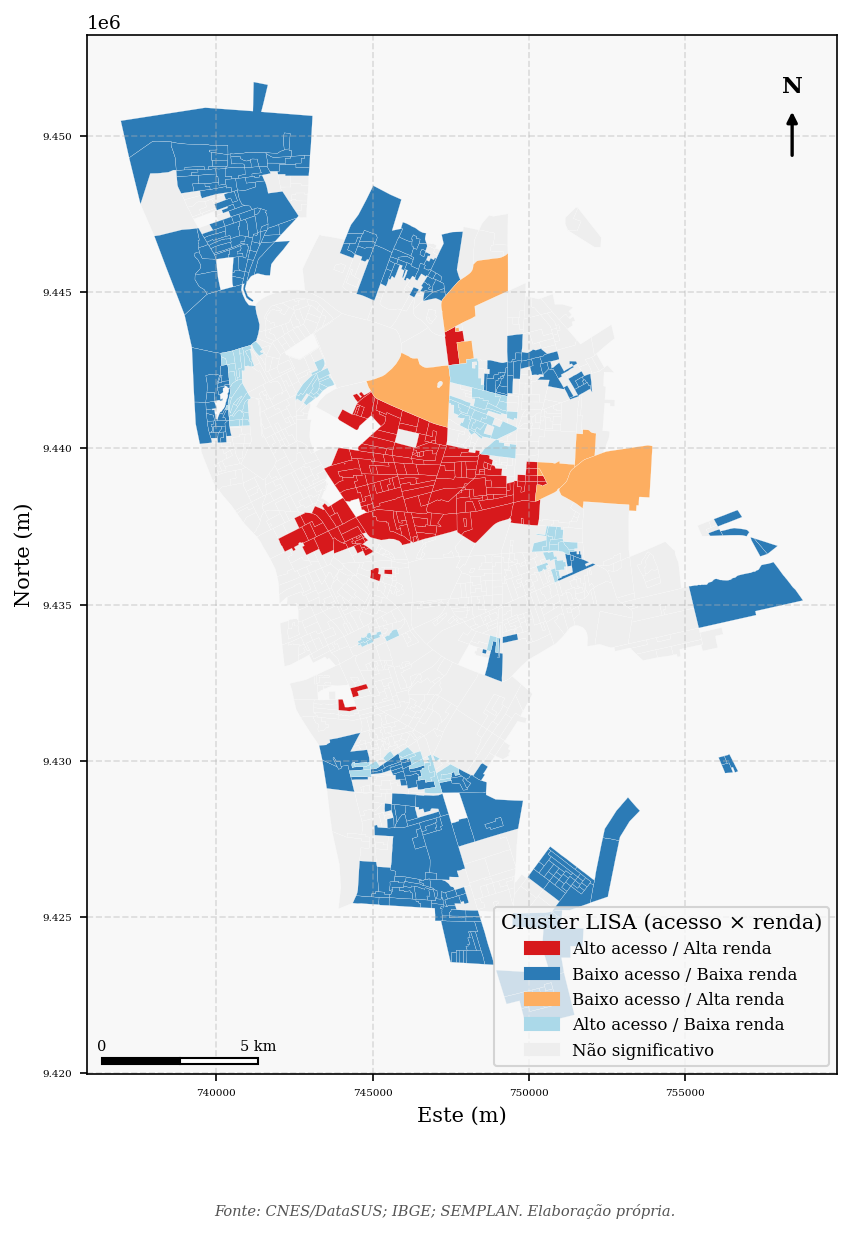

In [13]:
# ── Fig. 03 — Agrupamentos LISA (acesso carro × renda) ──────────────────────
CLUSTERS = {1: ("Alto acesso / Alta renda",   "#D7191C"),
            3: ("Baixo acesso / Baixa renda",  "#2C7BB6"),
            2: ("Baixo acesso / Alta renda",   "#FDAE61"),
            4: ("Alto acesso / Baixa renda",   "#ABD9E9")}
fig, ax = plt.subplots(figsize=(9, 9))
sub[~sub["sig"]].plot(ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.1)  # não-sig
handles = []
for q, (rotulo, cor) in CLUSTERS.items():
    g = sub[sub["sig"] & (sub["q"] == q)]
    if len(g):
        g.plot(ax=ax, color=cor, edgecolor="white", linewidth=0.1)
        handles.append(Patch(color=cor, label=rotulo))
handles.append(Patch(color="#EEEEEE", label="Não significativo"))
ax.legend(handles=handles, title="Cluster LISA (acesso × renda)", loc="lower right", fontsize=8)
moldura_mapa(ax, "", "CNES/DataSUS; IBGE; SEMPLAN. Elaboração própria.")
barra_escala(ax); seta_norte(ax)
plt.savefig(FIGURAS_NB / "nb061_fig03_h2_lisa.png", bbox_inches="tight")
plt.show()

## 5. Síntese dos testes
- **H1**: o diagnóstico areal concorda fortemente com o tradicional (ρ ≈ 0,99), mas
  reclassifica setores periféricos na margem, confirmando a relevância da correção areal.
- **H2**: a acessibilidade associa-se **positivamente** à renda (ρ ≈ +0,51) e exibe forte
  estrutura espacial (Moran I ≈ 0,92), com agrupamentos *baixo acesso–baixa renda* na
  periferia, confirmando a iniquidade territorial.
> ⚠️ O sentido observado é **positivo**, exigindo ajuste da redação da H2 (de "inversa" para
> "direta/positiva").

## 6. Modo pedestre e comparação entre modos

Repete-se o teste de H2 para o índice de acessibilidade a pé (`acess_pe`) e confrontam-se
os dois modos. A análise revela em que medida o diagnóstico de equidade depende do meio de
transporte considerado.

In [14]:
# ── 6. H2 — MODO PEDESTRE ───────────────────────────────────────────────────
subp = ac[ac["renda_media"].notna() & (ac["acess_pe"] > 0)].reset_index(drop=True)
rho_pe, p_pe = spearmanr(subp["acess_pe"], subp["renda_media"])
wp = KNN.from_dataframe(subp, k=8); wp.transform = "r"
moran_pe   = Moran(subp["acess_pe"].values, wp)
moranbv_pe = Moran_BV(subp["acess_pe"].values, subp["renda_media"].values, wp)
lisa_pe    = Moran_Local_BV(subp["acess_pe"].values, subp["renda_media"].values, wp, seed=42)
SIGp = lisa_pe.p_sim < 0.05
subp["cluster"] = np.where(SIGp, pd.Series(lisa_pe.q).map(ROTULO), "Não significativo")

n_sem_pe = int((ac["acess_pe"] == 0).sum())
print(f"H2 (pé) | Spearman acesso_pé×renda = {rho_pe:+.3f} (p={p_pe:.1e})")
print(f"   Moran I global (pé) = {moran_pe.I:.3f} | bivariado = {moranbv_pe.I:+.3f} (p={moranbv_pe.p_sim:.3f})")
print(f"   setores sem acesso a pé (deserto absoluto): {n_sem_pe} ({n_sem_pe/len(ac)*100:.1f}%)")
print("   clusters LISA (pé):"); print(subp.loc[SIGp, "cluster"].value_counts().to_string())

H2 (pé) | Spearman acesso_pé×renda = -0.153 (p=1.8e-08)
   Moran I global (pé) = 0.683 | bivariado = -0.260 (p=0.001)
   setores sem acesso a pé (deserto absoluto): 47 (3.3%)
   clusters LISA (pé):
cluster
Alto acesso–Baixa renda     252
Baixo acesso–Baixa renda    158
Baixo acesso–Alta renda     134
Alto acesso–Alta renda       13


In [15]:
# ── Fig. 04 — Agrupamentos LISA (acesso a pé × renda) ───────────────────────
fig, ax = plt.subplots(figsize=(9, 9))
subp[~subp["sig"]].plot(ax=ax, color="#EEEEEE", edgecolor="white", linewidth=0.1)
handles = []
for q, (rotulo, cor) in CLUSTERS.items():
    g = subp[subp["sig"] & (subp["q"] == q)]
    if len(g):
        g.plot(ax=ax, color=cor, edgecolor="white", linewidth=0.1)
        handles.append(Patch(color=cor, label=rotulo))
handles.append(Patch(color="#EEEEEE", label="Não significativo"))
ax.legend(handles=handles, title="Cluster LISA (acesso a pé × renda)", loc="lower right", fontsize=8)
moldura_mapa(ax, "", "CNES/DataSUS; IBGE; SEMPLAN. Elaboração própria.")
barra_escala(ax); seta_norte(ax)
plt.savefig(FIGURAS_NB / "nb061_fig04_h2_lisa_pe.png", bbox_inches="tight")
plt.show()

KeyError: 'sig'

Spearman acesso carro × pé = 0.094  (≈0 ⇒ padrões quase independentes)
Acesso × renda: carro = +0.508 | pé = -0.153  (inversão de sinal)


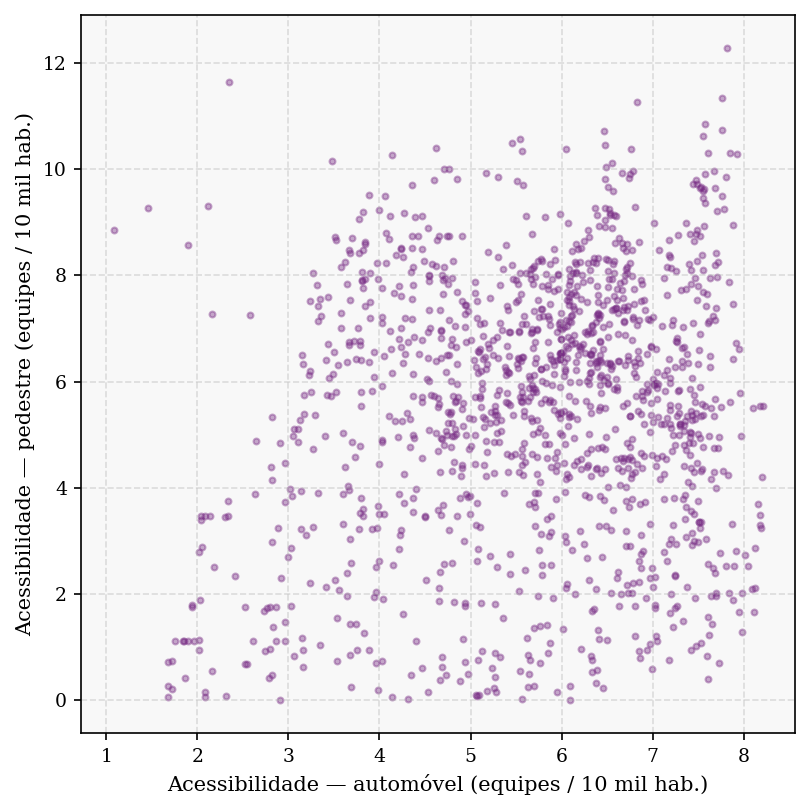

In [9]:
# ── 7. COMPARAÇÃO ENTRE MODOS ───────────────────────────────────────────────
comp = ac[(ac["acess_carro"] > 0) & (ac["acess_pe"] > 0)]
rho_modos, _ = spearmanr(comp["acess_carro"], comp["acess_pe"])
print(f"Spearman acesso carro × pé = {rho_modos:.3f}  (≈0 ⇒ padrões quase independentes)")
print(f"Acesso × renda: carro = {rho_h2:+.3f} | pé = {rho_pe:+.3f}  (inversão de sinal)")

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(comp["acess_carro"] * 1e4, comp["acess_pe"] * 1e4, s=8, alpha=0.4, color="#762A83")
ax.set_xlabel("Acessibilidade — automóvel (equipes / 10 mil hab.)")
ax.set_ylabel("Acessibilidade — pedestre (equipes / 10 mil hab.)")
plt.tight_layout()
plt.savefig(FIGURAS_NB / "nb061_fig05_comparacao_modos.png", bbox_inches="tight")
plt.show()

A acessibilidade a pé e a motorizada mostram-se praticamente independentes (ρ ≈ 0,09) e
de sinais opostos quanto à renda: positiva no automóvel (+0,51), negativa a pé (−0,15).
Por automóvel, a periferia de menor renda é desfavorecida; a pé, os bairros densos e mais
pobres dispõem de unidades próximas, ao passo que 47 setores periféricos não alcançam
nenhuma UBS caminhando em 30 minutos. A iniquidade de acesso revela-se, portanto,
condicionada pela dependência do automóvel.